In [29]:
import os
import re
import optuna
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import glob
import shap
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
def _infer_horizon_from_target(target_col):
    return int(re.search(r"_h(\d+)$", target_col).group(1))

In [11]:
def walk_forward_oos_with_shap(
    df,
    target_col,
    model_factory,
    feature_cols,
    train_size,
    test_size,
    step_size,
    horizon,
    expanding=False,
    save_path=None,
    shap_path=None,
    shap_importance_path=None,
    asset=None,
    objective=None,
):
    preds = []
    folds = []
    shap_values_all = []
    shap_importance_all = []

    n = len(df)
    fold_id = 0
    embargo = max(horizon - 1, 0)

    start_train = 0
    end_train = train_size

    while end_train + embargo < n:
        start_test = end_train + embargo
        end_test = min(start_test + test_size, n)

        if end_test <= start_test:
            break

        if expanding:
            train_idx = df.index[:end_train]
        else:
            train_idx = df.index[start_train:end_train]

        test_idx = df.index[start_test:end_test]

        X_train = df.loc[train_idx, feature_cols]
        y_train = df.loc[train_idx, target_col]

        X_test = df.loc[test_idx, feature_cols]
        y_test = df.loc[test_idx, target_col]

        model = model_factory()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        pred_df = pd.DataFrame(
            {
                "y_true": y_test.values,
                "y_pred": y_pred,
                "fold_id": fold_id,
            },
            index=test_idx,
        )

        preds.append(pred_df)

        folds.append(
            {
                "fold_id": fold_id,
                "train_start": train_idx[0],
                "train_end": train_idx[-1],
                "test_start": test_idx[0],
                "test_end": test_idx[-1],
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "horizon": horizon,
                "embargo": embargo,
            }
        )

        shap_df, shap_imp_df = compute_lgbm_shap(
            model=model,
            X=X_test,
            fold_id=fold_id,
            asset=asset,
            target_col=target_col,
            objective=objective,
        )

        shap_values_all.append(shap_df)
        shap_importance_all.append(shap_imp_df)

        fold_id += 1

        if expanding:
            end_train += step_size
        else:
            start_train += step_size
            end_train += step_size

    pred_df = pd.concat(preds)
    folds_df = pd.DataFrame(folds)
    shap_values_df = pd.concat(shap_values_all)
    shap_importance_df = pd.concat(shap_importance_all)

    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        pred_df.to_parquet(save_path)

    if shap_path is not None:
        Path(shap_path).parent.mkdir(parents=True, exist_ok=True)
        shap_values_df.to_parquet(shap_path)

    if shap_importance_path is not None:
        Path(shap_importance_path).parent.mkdir(parents=True, exist_ok=True)
        shap_importance_df.to_parquet(shap_importance_path)

    return pred_df, folds_df, shap_values_df, shap_importance_df

In [23]:
def _loss_by_objective(y_true, y_pred, objective, params=None):
    params = params or {}
    e = y_true - y_pred

    if objective in ["regression", "regression_l2"]:
        return np.mean(e ** 2)

    if objective == "regression_l1":
        return np.mean(np.abs(e))

    if objective == "huber":
        delta = params.get("alpha", 1.0)
        ae = np.abs(e)
        return np.mean(np.where(ae <= delta, 0.5 * e ** 2, delta * (ae - 0.5 * delta)))

    if objective == "fair":
        c = params.get("fair_c", 1.0)
        ae = np.abs(e)
        return np.mean(c ** 2 * (ae / c - np.log1p(ae / c)))

    if objective == "quantile":
        alpha = params.get("alpha", 0.5)
        return np.mean(np.maximum(alpha * e, (alpha - 1) * e))

    if objective == "mape":
        denom = np.where(np.abs(y_true) < 1e-8, np.nan, y_true)
        return np.nanmean(np.abs(e / denom))

    return np.mean(e ** 2)

In [18]:
def tune_lgbm_once(
    X,
    y,
    objective="regression",
    n_trials=50,
    random_seed=5,
    val_size=0.2,
):
    n_val = int(len(X) * val_size)

    X_tr = X.iloc[:-n_val]
    y_tr = y.iloc[:-n_val]
    X_val = X.iloc[-n_val:]
    y_val = y.iloc[-n_val:]

    def optuna_objective(trial):
        params = {
            "objective": objective,
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 7, 63),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "random_state": random_seed,
            "n_jobs": -1,
            "verbosity": -1,
        }

        if objective in ["huber", "quantile"]:
            params["alpha"] = trial.suggest_float("alpha", 0.50, 0.95)

        if objective == "fair":
            params["fair_c"] = trial.suggest_float("fair_c", 0.1, 10.0, log=True)

        model = LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)

        return _loss_by_objective(y_val.values, pred, objective, params=params)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=random_seed),
    )

    study.optimize(optuna_objective, n_trials=n_trials, show_progress_bar=False)

    return {
        **study.best_params,
        "objective": objective,
        "random_state": random_seed,
        "n_jobs": -1,
        "verbosity": -1,
    }

In [9]:
def make_lgbm_fixed(params):
    return LGBMRegressor(**params)


def compute_lgbm_shap(model, X, fold_id, asset, target_col, objective):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    shap_df = pd.DataFrame(
        shap_values,
        index=X.index,
        columns=X.columns,
    )

    shap_df["fold_id"] = fold_id
    shap_df["asset"] = asset
    shap_df["target_col"] = target_col
    shap_df["objective"] = objective

    importance_df = (
        shap_df[X.columns]
        .abs()
        .mean()
        .sort_values(ascending=False)
        .rename("mean_abs_shap")
        .reset_index()
        .rename(columns={"index": "feature"})
    )

    importance_df["fold_id"] = fold_id
    importance_df["asset"] = asset
    importance_df["target_col"] = target_col
    importance_df["objective"] = objective

    return shap_df, importance_df

In [10]:
def run_lgbm_oos_forecasts(
    features_targets,
    objectives=("regression", "regression_l1", "huber", "fair", "quantile", "mape"),
    n_trials=50,
    random_seed=5,
    train_size=252 * 5,
    test_size=63,
    step_size=63,
    expanding=False,
):
    out = {}

    for asset, df in features_targets.items():
        target_cols = [c for c in df.columns if c.startswith("target_")]
        feature_cols = [c for c in df.columns if not c.startswith("target_")]

        for target_col in target_cols:
            h = _infer_horizon_from_target(target_col)

            X_tune = df[feature_cols].iloc[:train_size]
            y_tune = df[target_col].iloc[:train_size]

            for objective in objectives:
                key = f"{asset}_{target_col}_{objective}"

                save_path = f"forecasts/{key}.parquet"
                shap_path = f"shap_values/{key}.parquet"
                shap_importance_path = f"shap_importance/{key}.parquet"

                best_params = tune_lgbm_once(
                    X=X_tune,
                    y=y_tune,
                    objective=objective,
                    n_trials=n_trials,
                    random_seed=random_seed,
                    val_size=0.2,
                )

                model_factory = lambda best_params=best_params: make_lgbm_fixed(best_params)

                pred_df, folds_df, shap_values_df, shap_importance_df = walk_forward_oos_with_shap(
                    df=df,
                    target_col=target_col,
                    model_factory=model_factory,
                    feature_cols=feature_cols,
                    train_size=train_size,
                    test_size=test_size,
                    step_size=step_size,
                    horizon=h,
                    expanding=expanding,
                    save_path=save_path,
                    shap_path=shap_path,
                    shap_importance_path=shap_importance_path,
                    asset=asset,
                    objective=objective,
                )

                out[key] = {
                    "preds": pred_df,
                    "folds": folds_df,
                    "shap_values": shap_values_df,
                    "shap_importance": shap_importance_df,
                    "path": save_path,
                    "shap_path": shap_path,
                    "shap_importance_path": shap_importance_path,
                    "best_params": best_params,
                }

    return out

In [12]:
files = sorted([f for f in glob.glob("data/*.parquet") if "gold_" in f])

In [20]:
features_targets = {}

dfs = []
for f in files:
    df = pd.read_parquet(f)
    dfs.append(df)

df_all = pd.concat(dfs, axis=1)
df_all = df_all.loc[:, ~df_all.columns.duplicated()]

features_targets["gold"] = df_all

In [13]:
def aggregate_shap_importance(shap_importance_df):
    return (
        shap_importance_df
        .groupby(["asset", "target_col", "objective", "feature"], as_index=False)
        ["mean_abs_shap"]
        .mean()
        .sort_values(["asset", "target_col", "objective", "mean_abs_shap"], ascending=[True, True, True, False])
    )

In [14]:
def top_shap_features(shap_importance_df, asset=None, target_col=None, objective=None, top_n=20):
    df = aggregate_shap_importance(shap_importance_df)

    if asset is not None:
        df = df[df["asset"] == asset]

    if target_col is not None:
        df = df[df["target_col"] == target_col]

    if objective is not None:
        df = df[df["objective"] == objective]

    return df.groupby(["asset", "target_col", "objective"]).head(top_n)

In [24]:
results = run_lgbm_oos_forecasts(
    features_targets=features_targets,
    objectives=("regression", "regression_l1", "huber", "fair", "quantile", "mape"),
    n_trials=50,
    random_seed=5,
    train_size=252 * 5,
    test_size=63,
    step_size=63,
    expanding=False,
)

[I 2026-04-25 21:22:13,784] A new study created in memory with name: no-name-59223953-6b69-4a33-a26b-22ac2b4d0161
[I 2026-04-25 21:22:14,067] Trial 0 finished with value: 0.0003206028583070138 and parameters: {'n_estimators': 300, 'learning_rate': 0.06789203913136307, 'num_leaves': 18, 'max_depth': 8, 'min_child_samples': 54, 'subsample': 0.8058719314513229, 'colsample_bytree': 0.8829539282401577, 'reg_alpha': 0.00046319289692831295, 'reg_lambda': 4.690342036615963e-06}. Best is trial 0 with value: 0.0003206028583070138.
[I 2026-04-25 21:22:14,269] Trial 1 finished with value: 0.00030534418812569605 and parameters: {'n_estimators': 269, 'learning_rate': 0.006368201795811424, 'num_leaves': 49, 'max_depth': 5, 'min_child_samples': 24, 'subsample': 0.9399685156006394, 'colsample_bytree': 0.6370432309961123, 'reg_alpha': 5.347061407655772e-05, 'reg_lambda': 4.6208236528276254e-06}. Best is trial 1 with value: 0.00030534418812569605.
[I 2026-04-25 21:22:14,516] Trial 2 finished with value: 

In [33]:
all_shap_importance = pd.concat(
    [
        v["shap_importance"]
        for k, v in results.items()
        if "shap_importance" in v
    ],
    ignore_index=True
)

In [41]:
target_col = "target_gold_h20"

shap_h = (
    aggregate_shap_importance(all_shap_importance)
    .query("asset == 'gold' and target_col == @target_col")
)

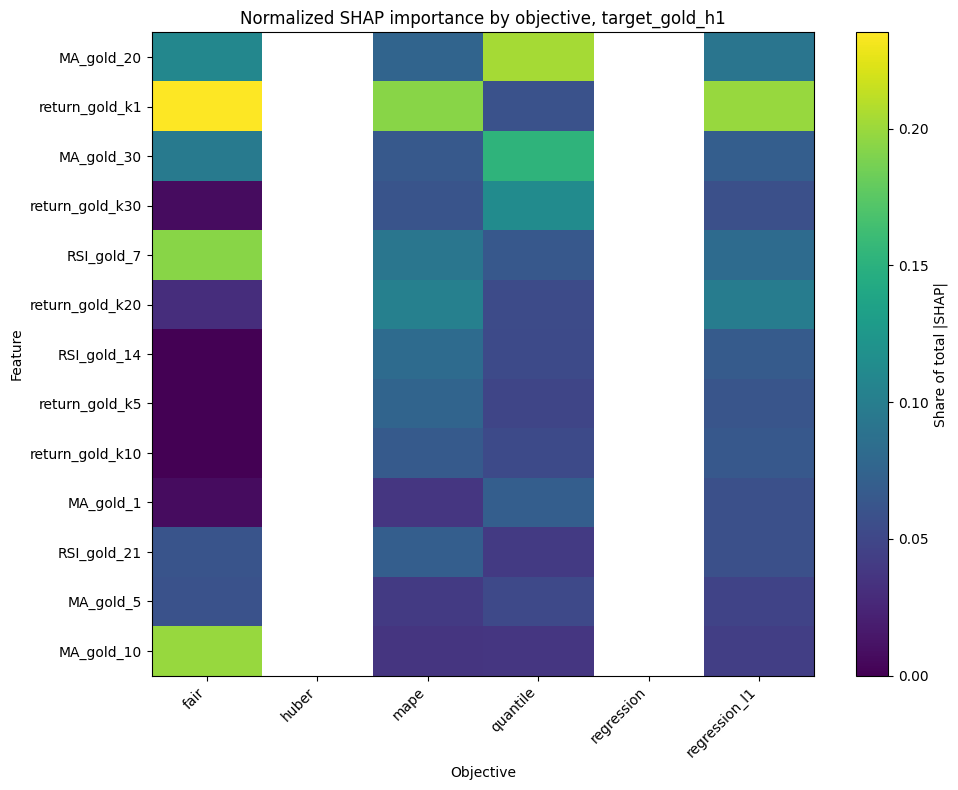

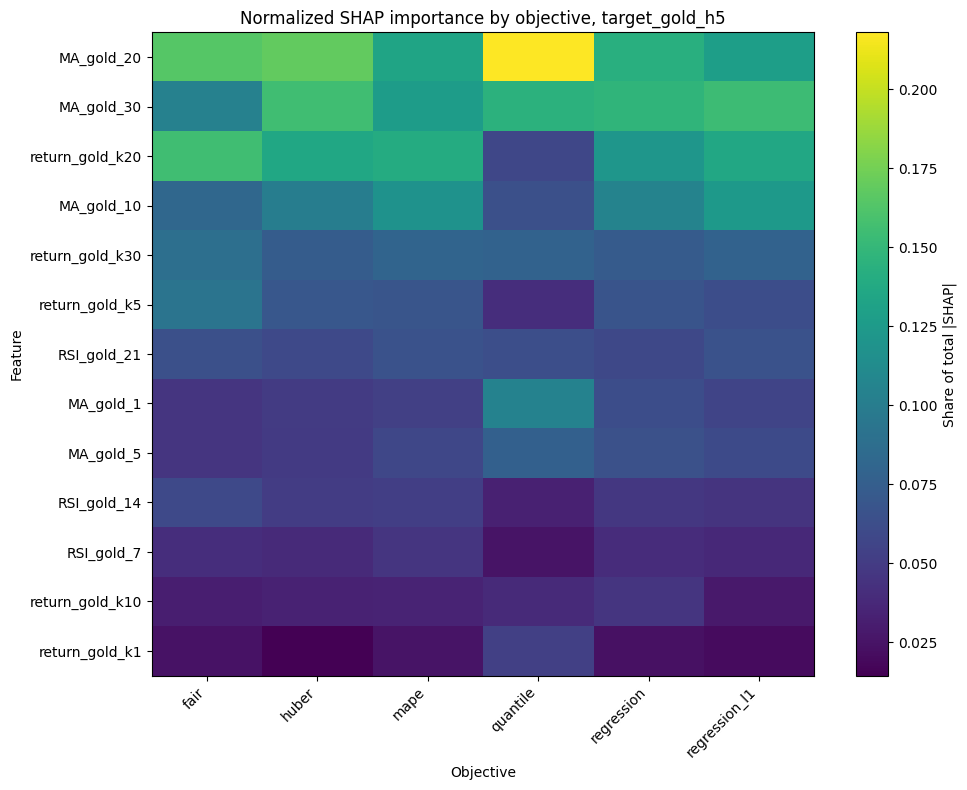

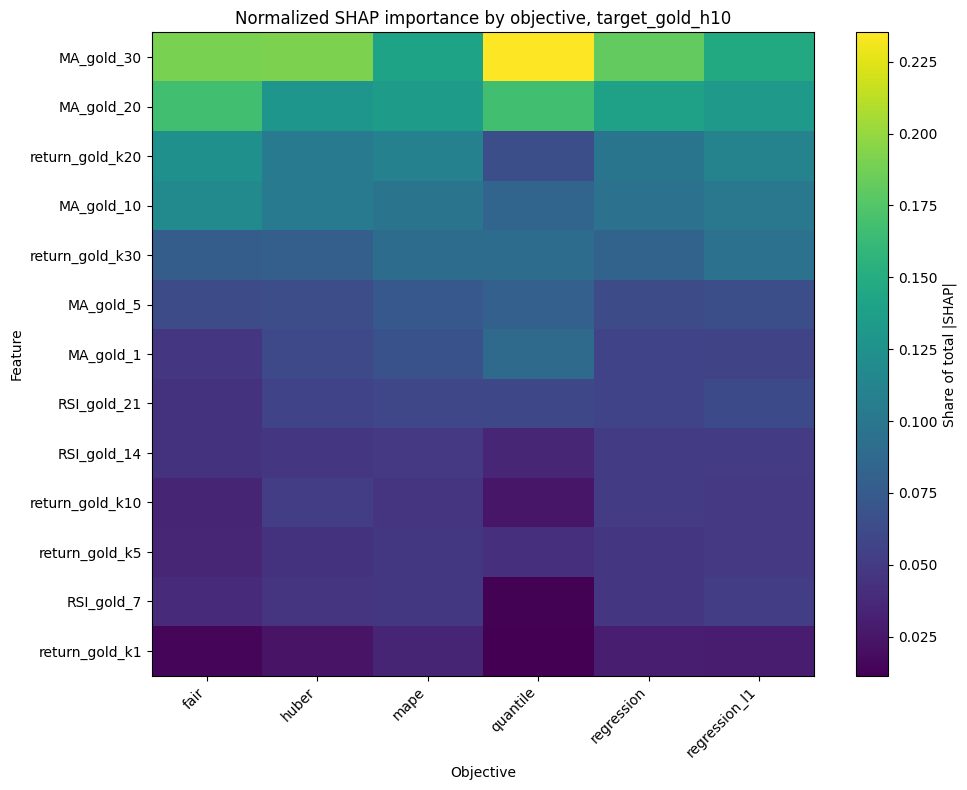

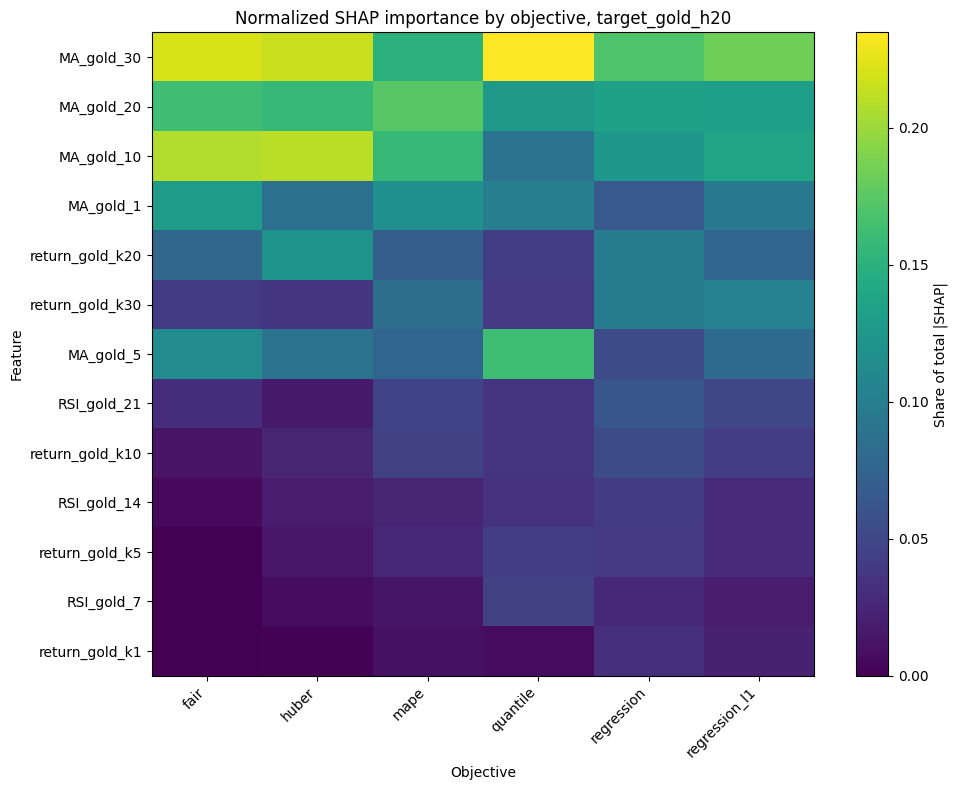

In [42]:
for h in [1, 5, 10, 20]:
    target_col = f"target_gold_h{h}"

    shap_h = (
        aggregate_shap_importance(all_shap_importance)
        .query("asset == 'gold' and target_col == @target_col")
    )

    top_features = (
        shap_h.groupby("feature")["mean_abs_shap"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
        .index
    )

    pivot_df = (
        shap_h[shap_h["feature"].isin(top_features)]
        .pivot(index="feature", columns="objective", values="mean_abs_shap")
        .loc[top_features]
    )

    pivot_norm = pivot_df.div(pivot_df.sum(axis=0), axis=1)

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(pivot_norm.values, aspect="auto")

    ax.set_xticks(range(len(pivot_norm.columns)))
    ax.set_xticklabels(pivot_norm.columns, rotation=45, ha="right")

    ax.set_yticks(range(len(pivot_norm.index)))
    ax.set_yticklabels(pivot_norm.index)

    ax.set_title(f"Normalized SHAP importance by objective, {target_col}")
    ax.set_xlabel("Objective")
    ax.set_ylabel("Feature")

    fig.colorbar(im, ax=ax, label="Share of total |SHAP|")

    plt.tight_layout()
    plt.show()